In [47]:
# First let's import the packages we will use in this project
import pandas as pd
import numpy as np
import seaborn as sns
import ast  # to parse strings as Python lists/dicts

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None




In [48]:

# Load the entire dataset with low_memory=False to handle mixed data types
df = pd.read_csv("/home/reen/Downloads/archive/movies_metadata.csv", low_memory=False)
df

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45461,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45462,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45463,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45464,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0


In [29]:
# Inspect the data
print(df.shape)
print(df.head())
print(df.columns)


(45466, 24)
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709                en   
1                                   NaN   8844  tt0113

In [49]:
# Print shape before conversion
print(f"Dataset shape before conversion: {df.shape}")

# Check if the columns exist in the dataset
existing_cols = [col for col in numeric_cols if col in df.columns]
missing_cols = [col for col in numeric_cols if col not in df.columns]

print(f"Columns found in dataset: {existing_cols}")
print(f"Columns NOT found in dataset: {missing_cols}")


Dataset shape before conversion: (45466, 24)
Columns found in dataset: ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']
Columns NOT found in dataset: []


In [50]:
# Convert columns that exist to numeric
numeric_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']
for col in existing_cols:
    print(f"Converting {col} to numeric...")
    df[col] = pd.to_numeric(df[col], errors='coerce')

Converting budget to numeric...
Converting revenue to numeric...
Converting popularity to numeric...
Converting vote_average to numeric...
Converting vote_count to numeric...


In [35]:
# Show sample after conversion
print("\nSample data after conversion:")
if existing_cols:
    print(df[existing_cols].head())
    


Sample data after conversion:
       budget      revenue  popularity  vote_average  vote_count
0  30000000.0  373554033.0   21.946943           7.7      5415.0
1  65000000.0  262797249.0   17.015539           6.9      2413.0
2         0.0          0.0   11.712900           6.5        92.0
3  16000000.0   81452156.0    3.859495           6.1        34.0
4         0.0   76578911.0    8.387519           5.7       173.0


In [36]:
# Check for NaN values after conversion
nan_counts = df[existing_cols].isna().sum()
print("\nNaN counts after conversion:")
print(nan_counts)


NaN counts after conversion:
budget          3
revenue         6
popularity      6
vote_average    6
vote_count      6
dtype: int64


In [56]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract the release year
df['year'] = df['release_date'].dt.year

#remove rows with missing release dates
df = df.dropna(subset=['release_date'])

# Make sure year exists
print(df[['title', 'release_date', 'year']].head())

# Quick check
print(df[['title', 'release_date', 'year']].head())

                         title release_date    year
0                    Toy Story   1995-10-30  1995.0
1                      Jumanji   1995-12-15  1995.0
2             Grumpier Old Men   1995-12-22  1995.0
3            Waiting to Exhale   1995-12-22  1995.0
4  Father of the Bride Part II   1995-02-10  1995.0
                         title release_date    year
0                    Toy Story   1995-10-30  1995.0
1                      Jumanji   1995-12-15  1995.0
2             Grumpier Old Men   1995-12-22  1995.0
3            Waiting to Exhale   1995-12-22  1995.0
4  Father of the Bride Part II   1995-02-10  1995.0


In [57]:

def get_main_genre(x):
    try:
        genres = ast.literal_eval(x)  # convert string to list of dicts
        if genres:
            return genres[0]['name']  # pick first genre
        else:
            return np.nan
    except:
        return np.nan

df['main_genre'] = df['genres'].apply(get_main_genre)

# Check unique genres
print(df['main_genre'].value_counts().head(10))


main_genre
Drama          11961
Comedy          8819
Action          4486
Documentary     3404
Horror          2619
Crime           1684
Thriller        1665
Adventure       1513
Romance         1191
Animation       1122
Name: count, dtype: int64


In [58]:
#Calculate  Profit and ROI
df['profit'] = df['revenue'] - df['budget']
df['roi'] = df['profit'] / df['budget'].replace(0, np.nan)  # avoid divide by zero

# Create decade
df['decade'] = (df['year'] // 10) * 10

# Quick check
print(df[['title', 'budget', 'revenue', 'profit', 'roi', 'year', 'decade']].head())


                         title      budget      revenue       profit  \
0                    Toy Story  30000000.0  373554033.0  343554033.0   
1                      Jumanji  65000000.0  262797249.0  197797249.0   
2             Grumpier Old Men         0.0          0.0          0.0   
3            Waiting to Exhale  16000000.0   81452156.0   65452156.0   
4  Father of the Bride Part II         0.0   76578911.0   76578911.0   

         roi    year  decade  
0  11.451801  1995.0  1990.0  
1   3.043035  1995.0  1990.0  
2        NaN  1995.0  1990.0  
3   4.090760  1995.0  1990.0  
4        NaN  1995.0  1990.0  


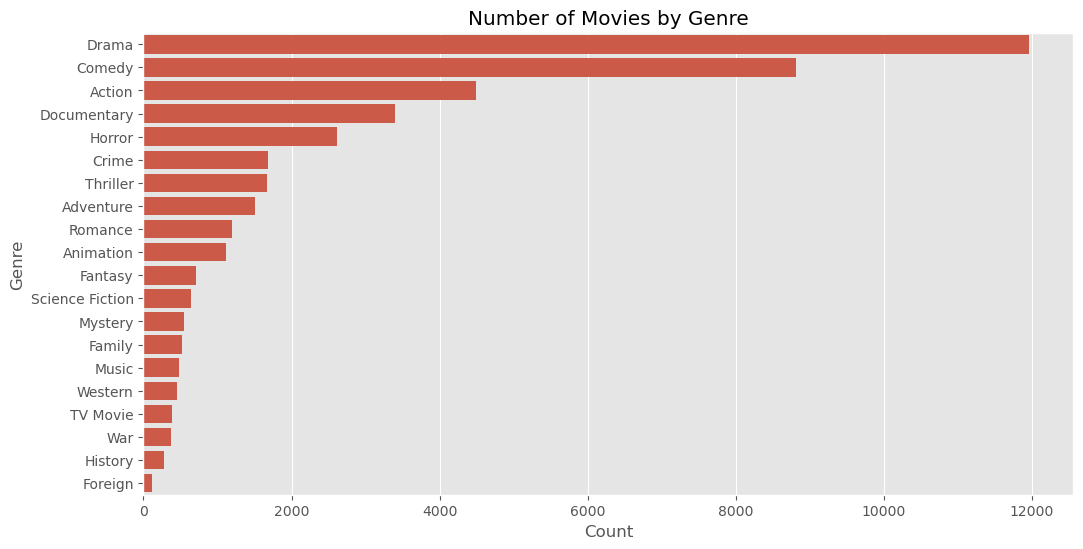

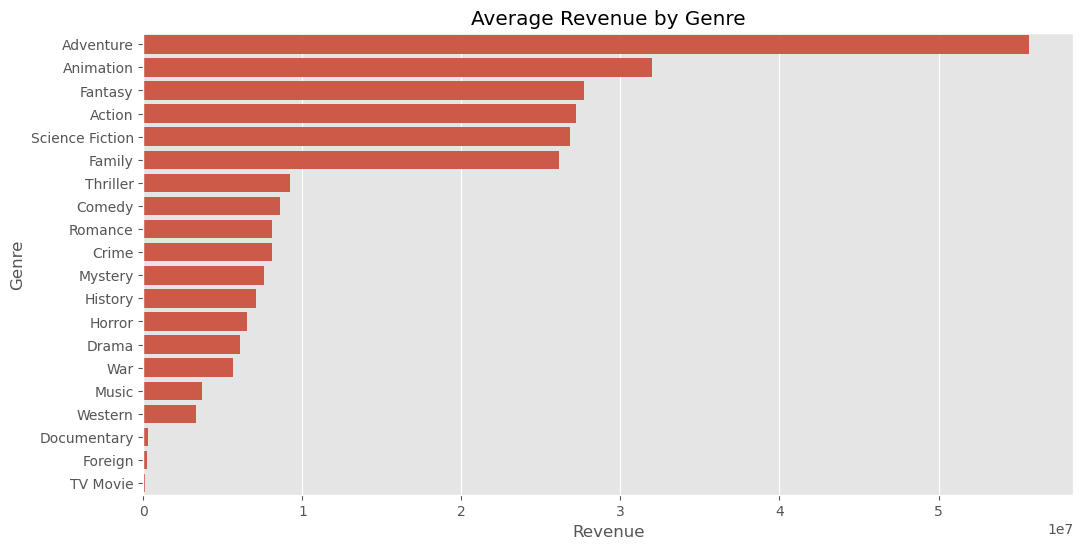

In [59]:
# Count of movies by genre
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='main_genre', order=df['main_genre'].value_counts().index)
plt.title('Number of Movies by Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# Average revenue by genre
avg_revenue_genre = df.groupby('main_genre')['revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=avg_revenue_genre.values, y=avg_revenue_genre.index)
plt.title('Average Revenue by Genre')
plt.xlabel('Revenue')
plt.ylabel('Genre')
plt.show()


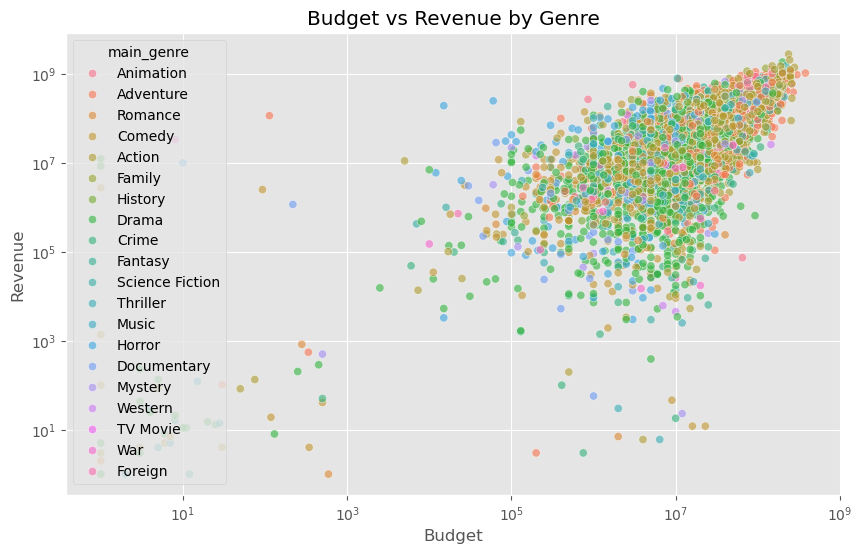

In [60]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='budget', y='revenue', hue='main_genre', alpha=0.6)
plt.title('Budget vs Revenue by Genre')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.xscale('log')
plt.yscale('log')
plt.show()


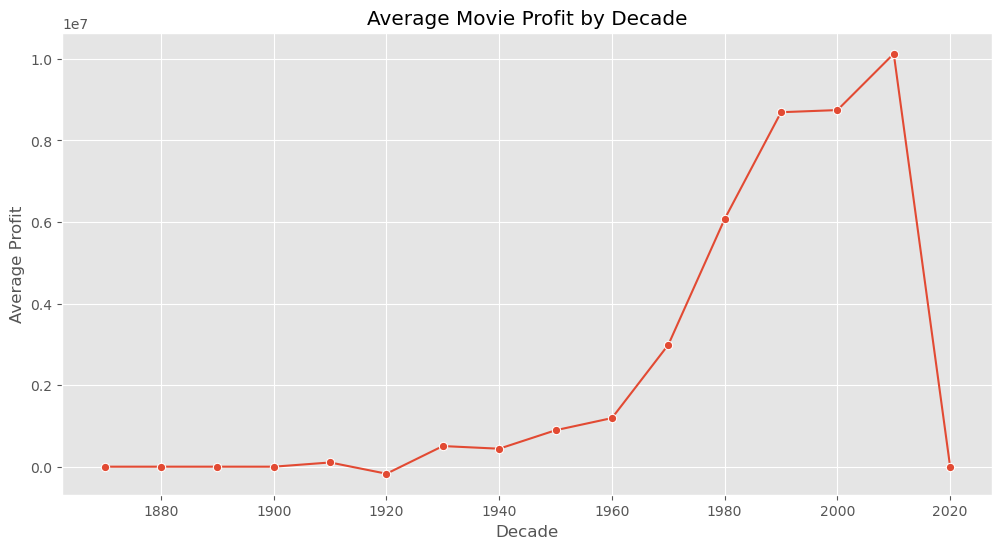

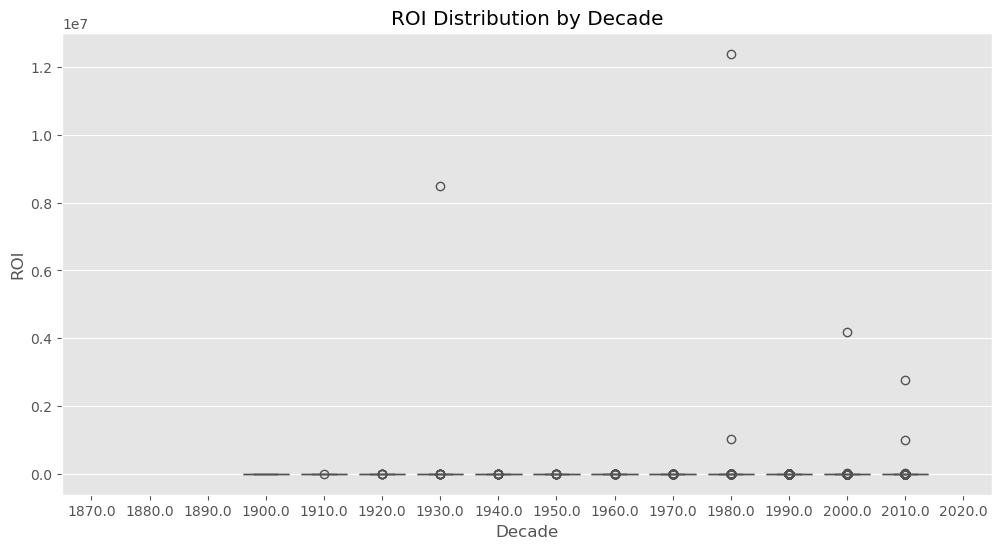

In [61]:
# Average profit by decade
avg_profit_decade = df.groupby('decade')['profit'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=avg_profit_decade.index, y=avg_profit_decade.values, marker='o')
plt.title('Average Movie Profit by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Profit')
plt.show()

# ROI distribution by decade
plt.figure(figsize=(12,6))
sns.boxplot(x='decade', y='roi', data=df)
plt.title('ROI Distribution by Decade')
plt.xlabel('Decade')
plt.ylabel('ROI')
plt.show()


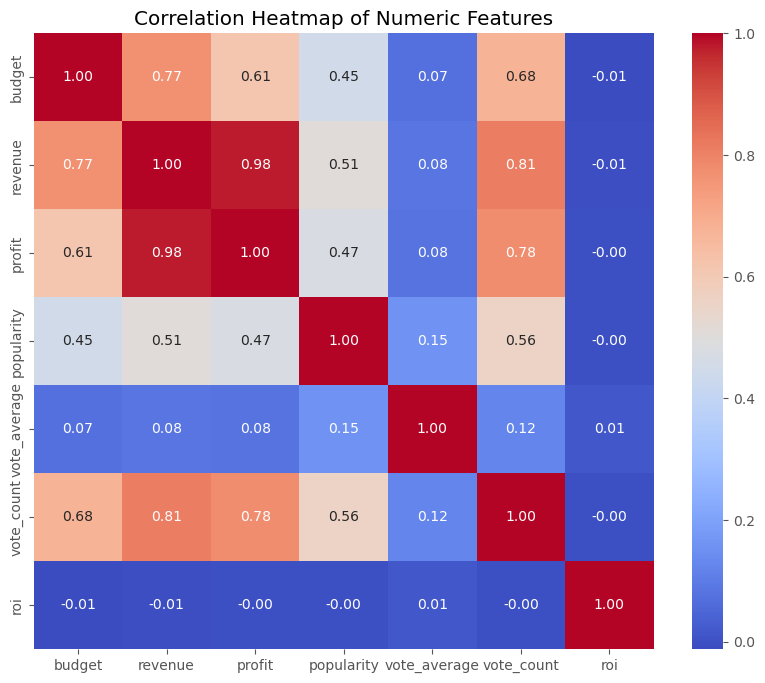

In [62]:
numeric_features = ['budget', 'revenue', 'profit', 'popularity', 'vote_average', 'vote_count', 'roi']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


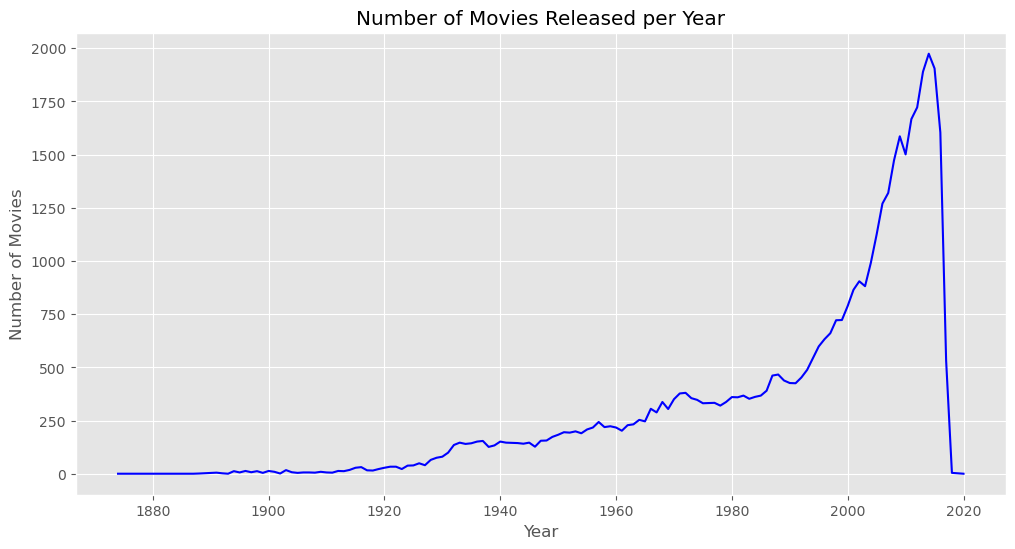

In [63]:
# Count movies released each year
movies_per_year = df.groupby('year').size()

plt.figure(figsize=(12,6))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, color="blue")
plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()


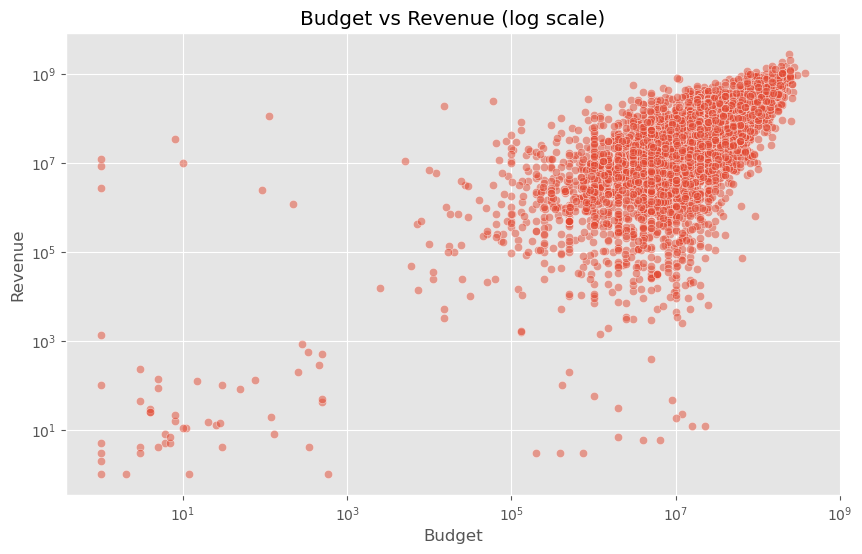

In [64]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.5)
plt.xscale("log")  # log scale since budgets vary a lot
plt.yscale("log")
plt.title("Budget vs Revenue (log scale)")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()


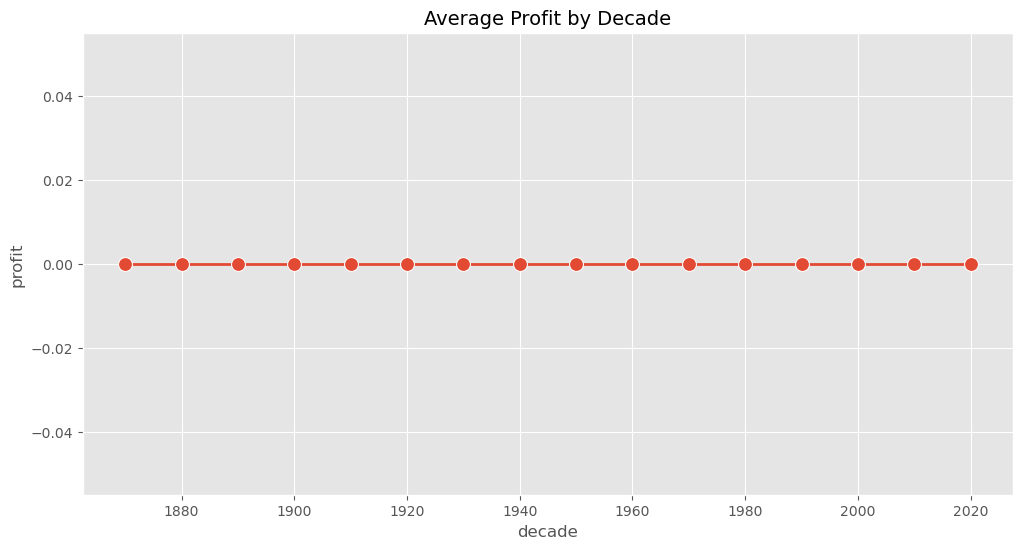

In [79]:
# Convert Series to DataFrame
profit_df = profit_by_decade.reset_index()
profit_df.columns = ['decade', 'profit']
#plot show
plt.figure(figsize=(12, 6))
sns.lineplot(data=profit_df, x='decade', y='profit', marker='o', linewidth=2, markersize=10)
plt.grid(True)
plt.title("Average Profit by Decade", fontsize=14)
plt.show()

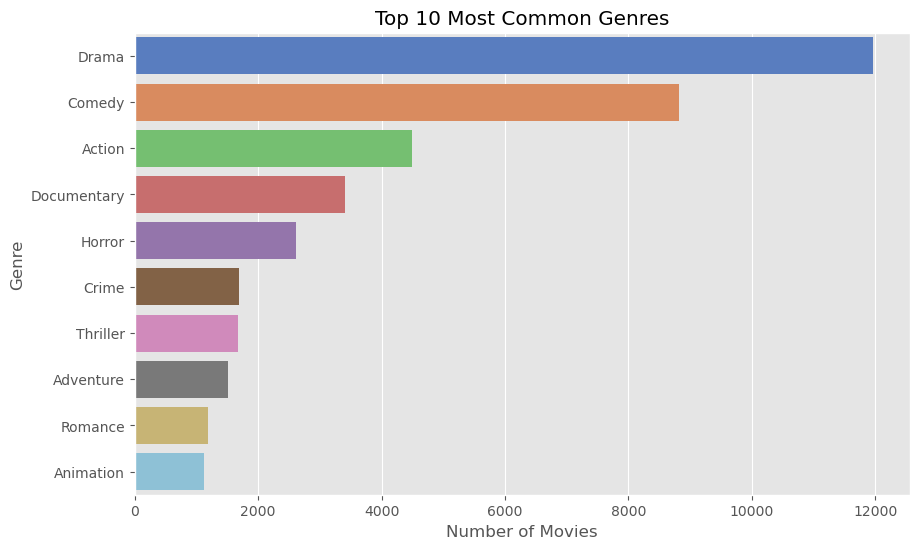

In [82]:
# Count movies by main_genre
genre_counts = df['main_genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette="muted", legend=False)
plt.title("Top 10 Most Common Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()


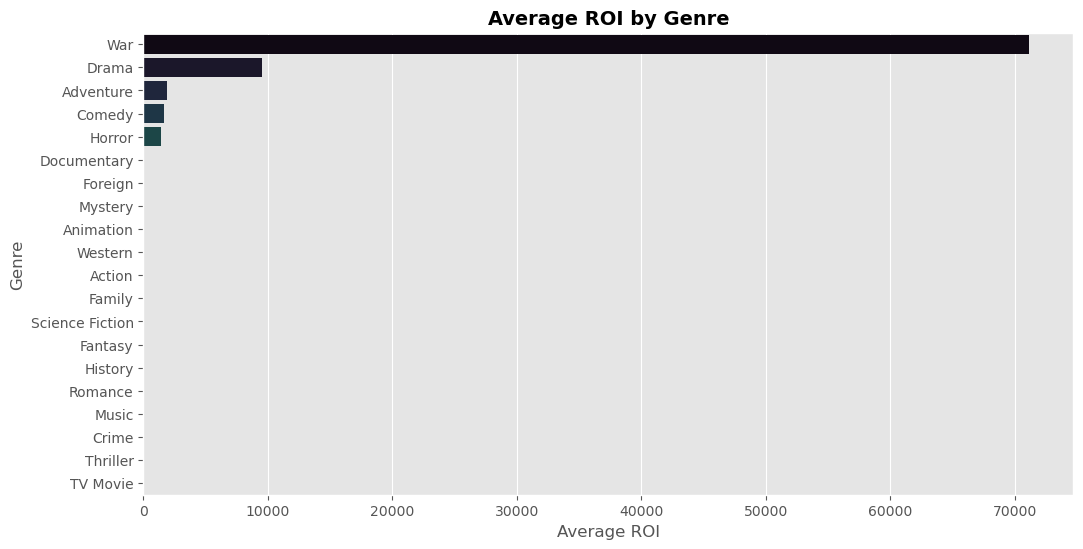

In [84]:
# Group by genre and calculate average ROI
roi_by_genre = df.groupby('main_genre')['roi'].mean().sort_values(ascending=False)

# Convert to DataFrame
roi_df = roi_by_genre.reset_index()
roi_df.columns = ['main_genre', 'avg_roi']

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=roi_df, x='avg_roi', y='main_genre', hue='main_genre', palette="cubehelix", legend=False) 
plt.title("Average ROI by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Average ROI")
plt.ylabel("Genre")
plt.show()


                                              title    year        profit  \
14551                                        Avatar  2009.0  2.550965e+09   
26555                  Star Wars: The Force Awakens  2015.0  1.823224e+09   
1639                                        Titanic  1997.0  1.645034e+09   
25084                                Jurassic World  2015.0  1.363529e+09   
28830                                     Furious 7  2015.0  1.316249e+09   
17818                                  The Avengers  2012.0  1.299558e+09   
17437  Harry Potter and the Deathly Hallows: Part 2  2011.0  1.217000e+09   
26558                       Avengers: Age of Ultron  2015.0  1.125404e+09   
22110                                        Frozen  2013.0  1.124219e+09   
42222                          Beauty and the Beast  2017.0  1.102886e+09   

            revenue       budget  
14551  2.787965e+09  237000000.0  
26555  2.068224e+09  245000000.0  
1639   1.845034e+09  200000000.0  
25084  1.513

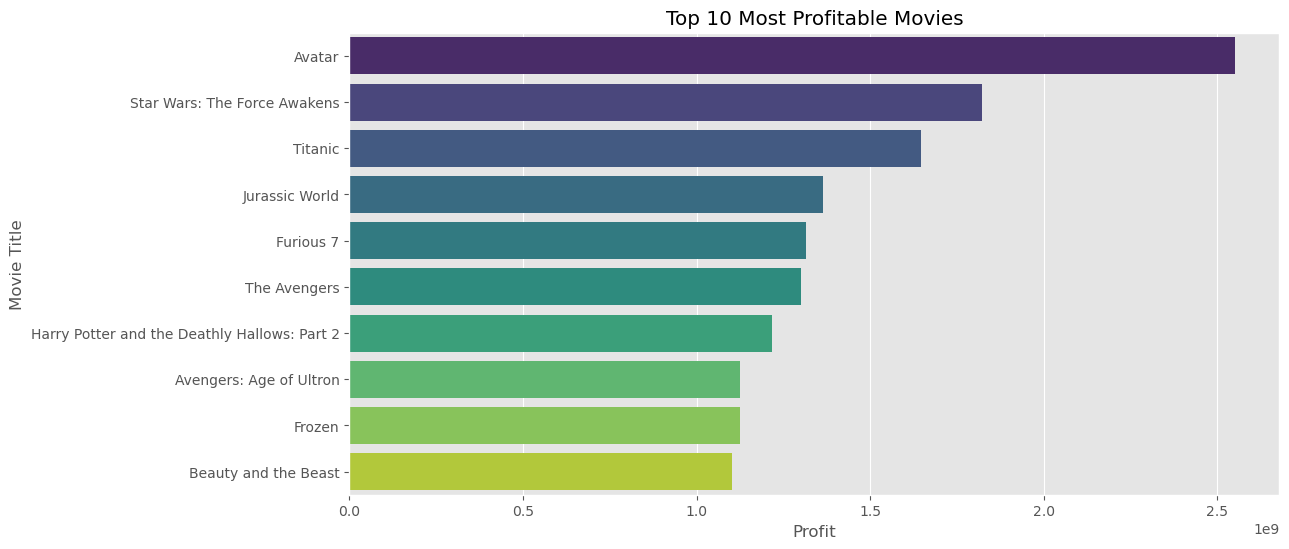

In [86]:
# Top 10 profitable movies
top10_profit = df.sort_values(by="profit", ascending=False).head(10)
print(top10_profit[['title', 'year', 'profit', 'revenue', 'budget']])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=top10_profit, x='profit', y='title', hue='title', palette="viridis", legend=False)
plt.title("Top 10 Most Profitable Movies")
plt.xlabel("Profit")
plt.ylabel("Movie Title")
plt.show()


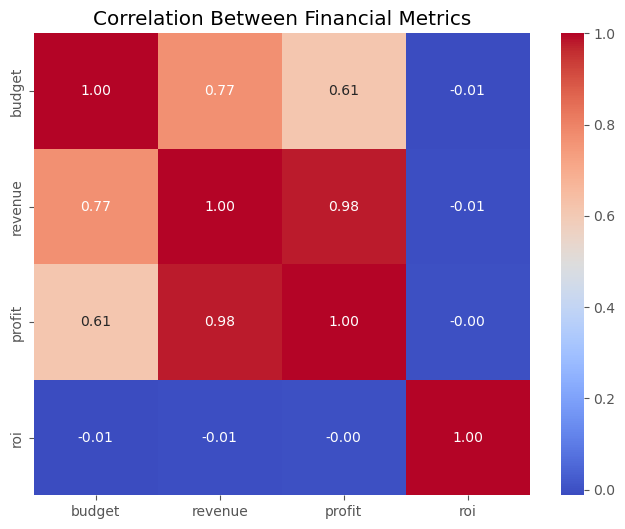

In [87]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['budget','revenue','profit','roi']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Financial Metrics")
plt.show()


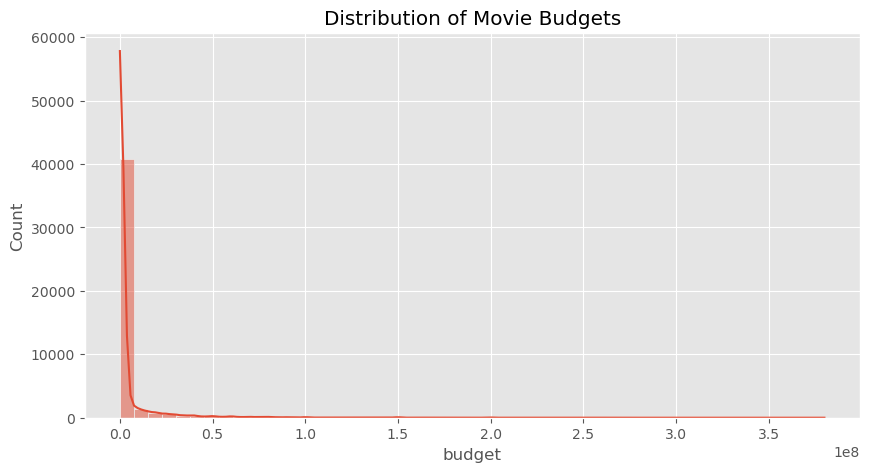

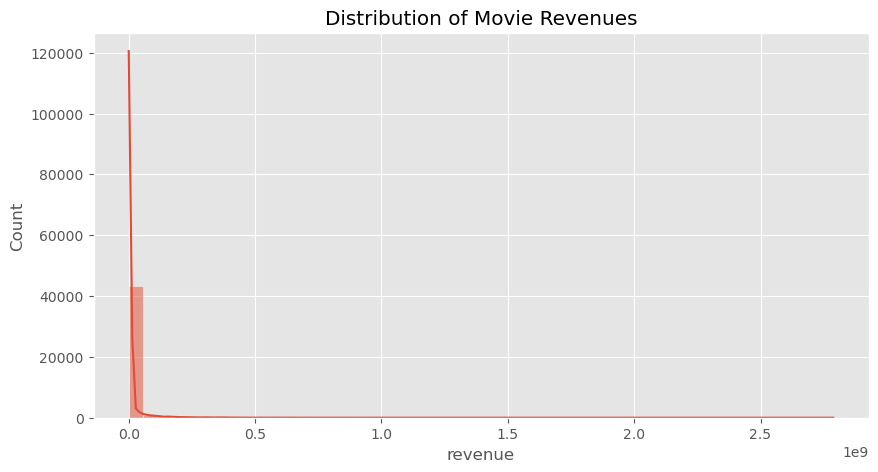

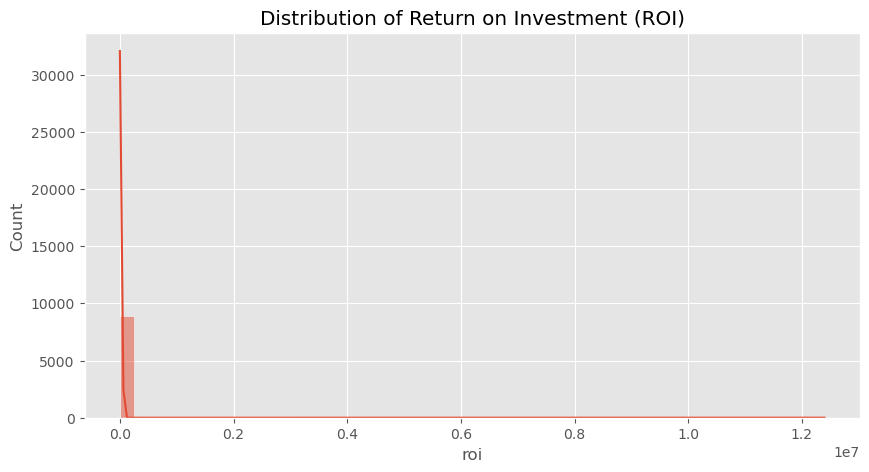

In [88]:
# Budget distribution
plt.figure(figsize=(10,5))
sns.histplot(df['budget'], bins=50, kde=True)
plt.title("Distribution of Movie Budgets")
plt.show()

# Revenue distribution
plt.figure(figsize=(10,5))
sns.histplot(df['revenue'], bins=50, kde=True)
plt.title("Distribution of Movie Revenues")
plt.show()

# ROI distribution
plt.figure(figsize=(10,5))
sns.histplot(df['roi'], bins=50, kde=True)
plt.title("Distribution of Return on Investment (ROI)")
plt.show()


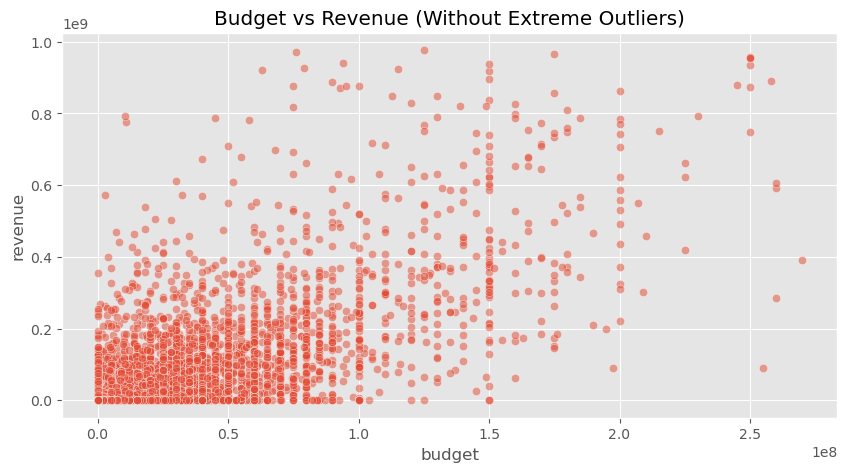

In [89]:
# Remove extreme values for cleaner plots 
df_filtered = df[(df['budget'] < 3e8) & (df['revenue'] < 1e9)]  

plt.figure(figsize=(10,5))
sns.scatterplot(data=df_filtered, x="budget", y="revenue", alpha=0.5)
plt.title("Budget vs Revenue (Without Extreme Outliers)")
plt.show()
